In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid',palette='tab10')

plt.rcParams["figure.dpi"]=120
plt.rcParams["font.size"]=11


proj_root = Path.cwd().parent
features_path = proj_root/"data"/"processed"/"sdss_features.csv"
clean_path = proj_root/"data"/"processed"/"sdss_clean.csv"

print(features_path.exists())
print(clean_path.exists())


True
True


In [6]:
df = pd.read_csv(features_path)
print(f"Loaded {features_path} with shape {df.shape}")
print(df["target"].value_counts())
print(df.head())

raw_bands = ['u','g','r','i','z']
colors = ['u_g','g_r','r_i','i_z']

Loaded /home/sunspritejsp/dev/projs/sdss-quasar-classification/data/processed/sdss_features.csv with shape (99954, 10)
target
0    49995
1    49959
Name: count, dtype: int64
          u         g         r         i         z      u_g      g_r  \
0  20.78556  20.64296  20.08354  19.78511  19.81030  0.14260  0.55942   
1  17.09996  16.16042  15.89365  15.81271  15.78566  0.93954  0.26677   
2  19.12911  18.97812  19.03414  19.25292  19.06842  0.15099 -0.05602   
3  20.59022  20.52769  20.35182  20.33298  20.56437  0.06253  0.17587   
4  19.56240  19.18494  18.63504  18.38647  17.98028  0.37746  0.54990   

       r_i      i_z  target  
0  0.29843 -0.02519       1  
1  0.08094  0.02705       0  
2 -0.21878  0.18450       1  
3  0.01884 -0.23139       1  
4  0.24857  0.40619       1  


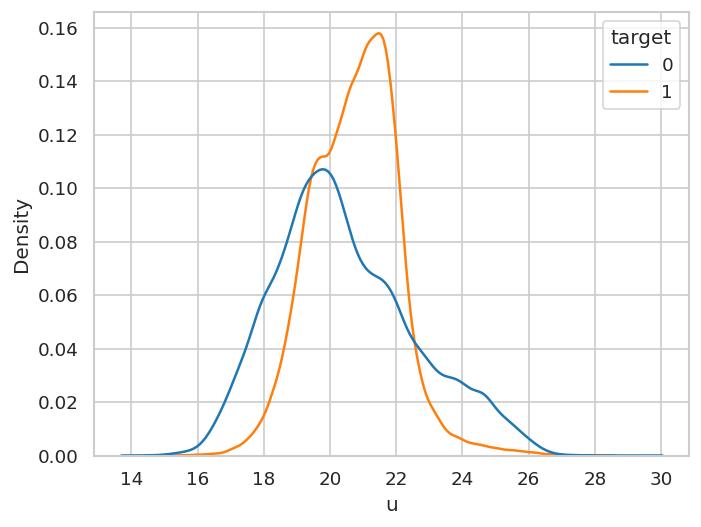

In [7]:
sns.kdeplot(data=df,x='u',hue='target')
plt.show()

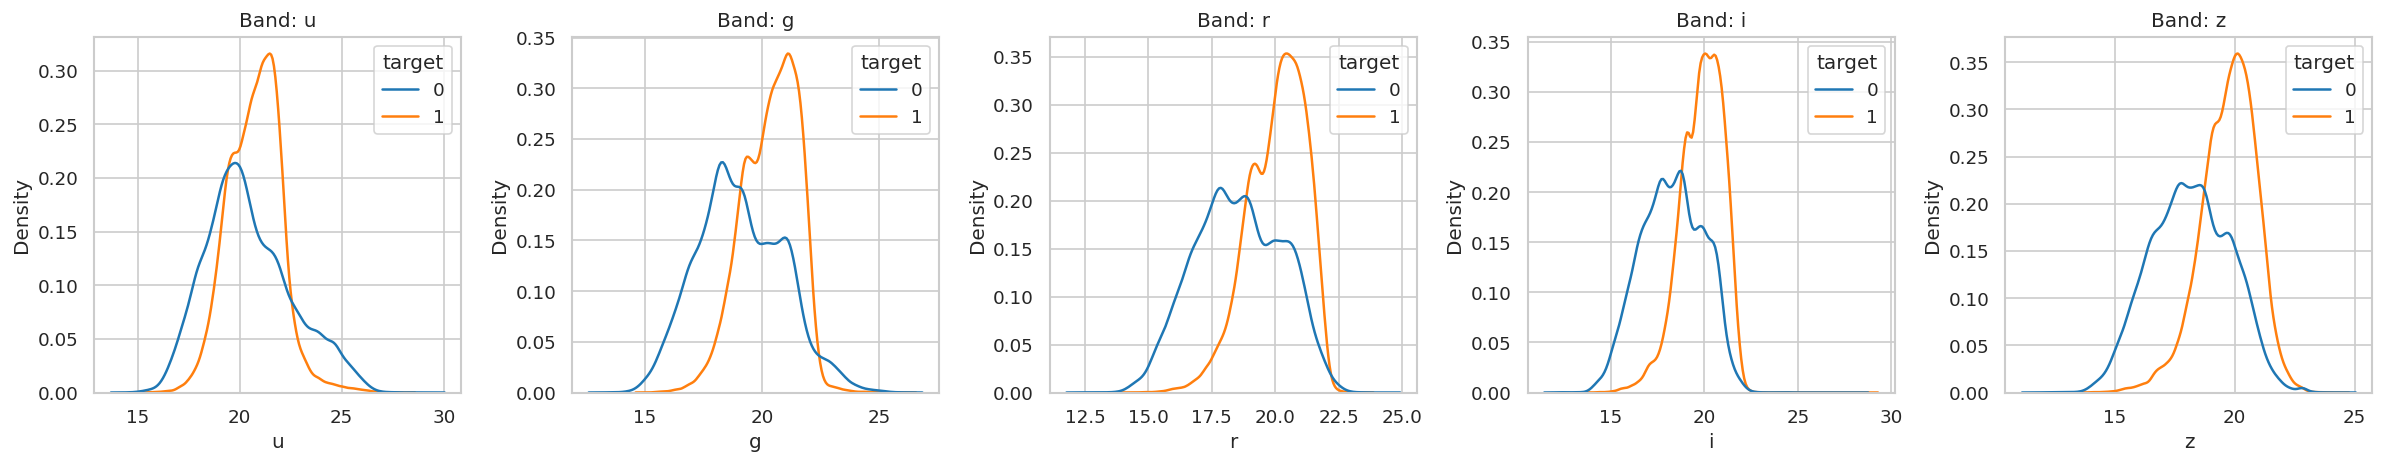

In [11]:
fig, axes = plt.subplots(1, 5 ,figsize=(20,4))

for i, band in enumerate(raw_bands):
    sns.kdeplot(data=df, x=band, hue='target', common_norm=False, ax=axes[i])
    axes[i].set_title(f"Band: {band}")

plt.tight_layout()
plt.show()

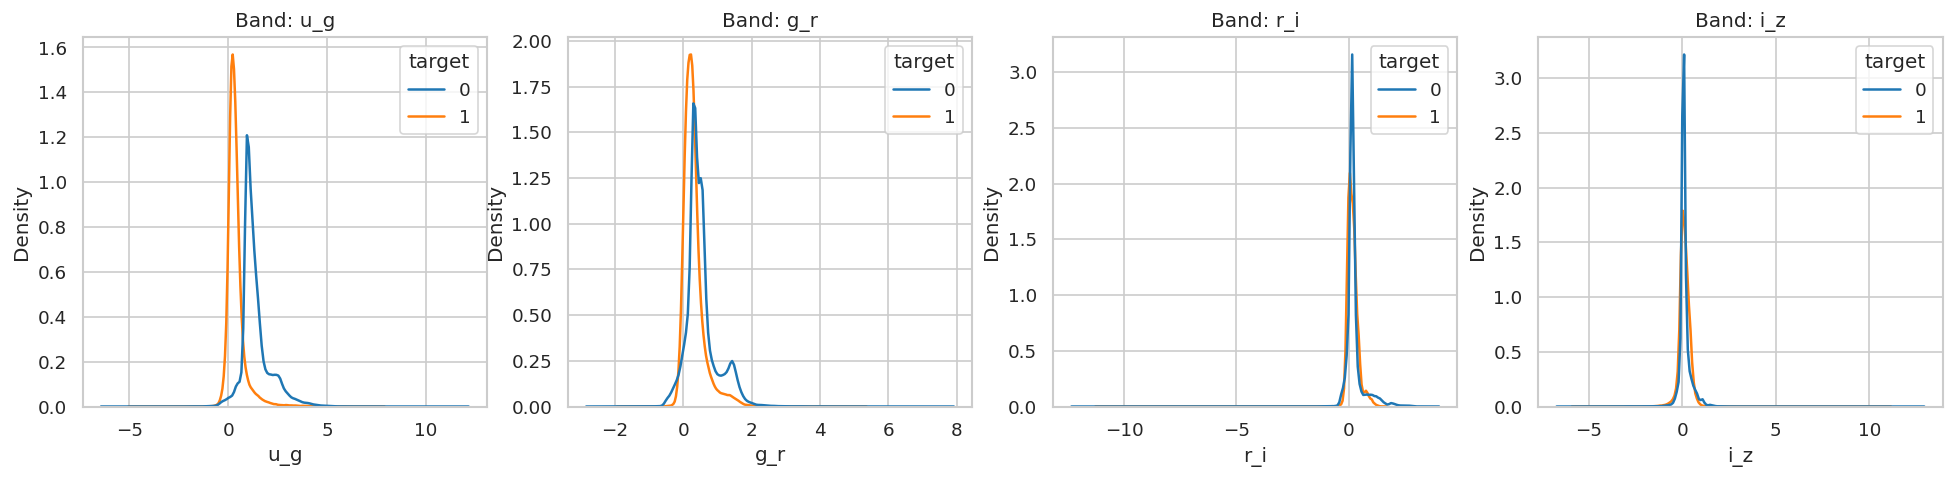

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20,4))

for i, band in enumerate(colors):
    sns.kdeplot(data=df,x=band,hue='target', common_norm=False, ax=axes[i])
    axes[i].set_title(f"Band: {band}")

#plt.tight_layout()
plt.show()

this is so cool im having so much fun

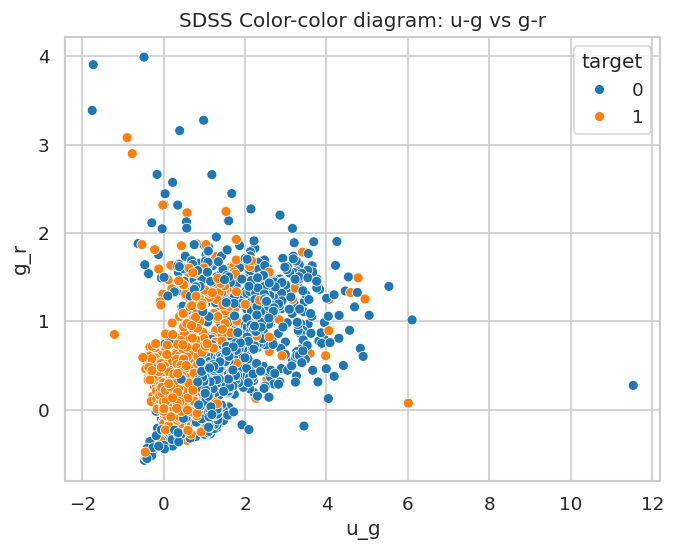

In [16]:
sample = df.sample(5000, random_state=13)
                   
sns.scatterplot(data=sample, x='u_g', y='g_r', hue='target')
plt.title("SDSS Color-color diagram: u-g vs g-r")
plt.show()